In [1]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split , cross_val_score
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
import pandas as pd


mercari_df= pd.read_csv('../data/mercari_train.tsv',sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(1482535, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


In [2]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  str    
 4   brand_name         849853 non-null   str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  str    
dtypes: float64(1), int64(3), str(4)
memory usage: 90.5 MB


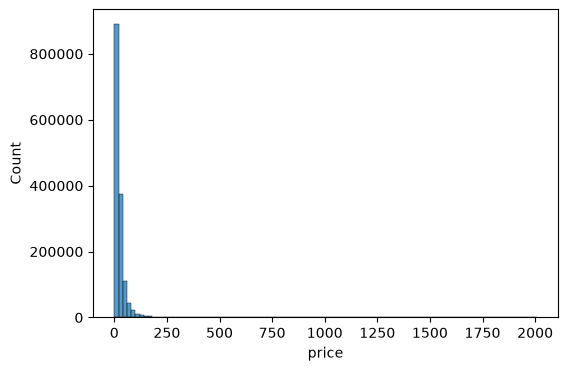

In [3]:
# 가격 분포 확인
import matplotlib.pyplot as plt
import seaborn as sns


y_train_df = mercari_df['price']
plt.figure(figsize=(6,4))
sns.histplot(y_train_df, bins=100)
plt.show()

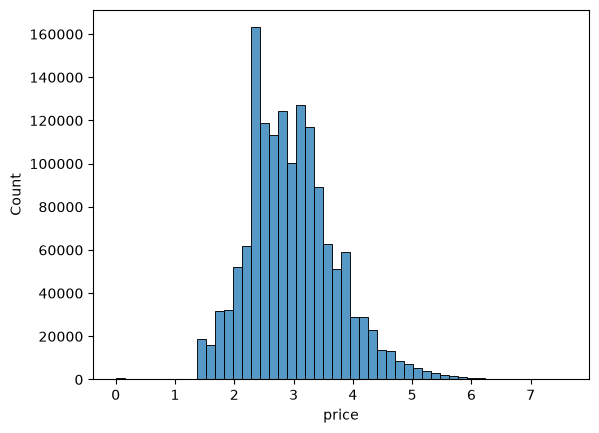

In [4]:
import numpy as np


y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

In [5]:
# price 값의 분포가 왼쪽에 몰려있으므로 price에 log처리

mercari_df['price'] = np.log1p(mercari_df['price'])
mercari_df['price'].head(3)


0    2.397895
1    3.970292
2    2.397895
Name: price, dtype: float64

In [6]:
print('Shipping 값 유형:\n',mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n',mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    819435
1    663100
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    640549
3    432161
2    375479
4     31962
5      2384
Name: count, dtype: int64


In [7]:
# 카테고리: 대 / 중 / 소
# apply lambda에서 호출되는 대,중,소 분할 함수 생성, 대,중,소 값을 리스트 반환
def split_cat(category_name):
    try:
        return category_name.split('/')
    except:
        return ['Other_Null' , 'Other_Null' , 'Other_Null']


# 위의 split_cat( )을 apply lambda에서 호출하여 대,중,소 컬럼을 mercari_df에 생성.
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
                        zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))


# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 갯수만 추출
print('대분류 유형 :\n', mercari_df['cat_dae'].value_counts())
print('중분류 갯수 :', mercari_df['cat_jung'].nunique())
print('소분류 갯수 :', mercari_df['cat_so'].nunique())


대분류 유형 :
 cat_dae
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Other_Null                  6327
Name: count, dtype: int64
중분류 갯수 : 114
소분류 갯수 : 871


In [8]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')


# 각 컬럼별로 Null값 건수 확인. 모두 0가 나와야 합니다.
mercari_df.isnull().sum()

train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
cat_dae              0
cat_jung             0
cat_so               0
dtype: int64

In [9]:
mercari_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  str    
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1482535 non-null  str    
 4   brand_name         1482535 non-null  str    
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482535 non-null  str    
 8   cat_dae            1482535 non-null  str    
 9   cat_jung           1482535 non-null  str    
 10  cat_so             1482535 non-null  str    
dtypes: float64(1), int64(3), str(7)
memory usage: 124.4 MB


In [10]:
# name 속성에 대한 feature vectorization 변환
# name은 평균 길이가 짧아 단어별 빈도가 대부분 1 근처(TF에서 차이 파악 어려움.)
# 저빈도 노이즈 토큰 제거를 위해 min_df 2 적용
# min_df: 단어가 등장해야 하는 최소 문서(row) 수. 이 값 미만으로 등장한 단어는 피처에서 제외
#   - 값을 높이면: 오타/희귀어 등 노이즈 단어가 더 많이 걸러져 피처 수가 줄고 학습 속도가 빨라지지만, 드물게 등장하는 유의미한 단어까지 잃을 위험이 커짐
#   - 값을 낮추면(1에 가까울수록): 거의 모든 단어가 피처로 남아 정보 손실은 적지만, 노이즈와 차원 수가 늘어 메모리/연산 부담과 과적합 위험이 커짐
cnt_vec = CountVectorizer(min_df=2)
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description 에 대한 feature vectorization 변환
# item_description은 평균 길이가 길고 문서 전반에 쓰이는 단어 사용이 많음.
# 핵심 단어에 가중치를 두기 위해 TFIDF 사용.
# ngram(1,3): 한 단어, 두 단어, 세 단어로 연결된 단어들 확인
# max_features=50000: 3-gram으로 인한 차원 폭발을 feature 50000으로 제한.
# max_features: 등장 빈도가 높은 순으로 상위 몇 개의 단어(조합)만 피처로 사용할지 지정
#   - 값을 높이면: 더 많은 단어 조합을 피처로 반영해 표현력은 늘지만, 피처(컬럼) 수가 늘어 메모리 사용량과 연산 시간이 증가하고 과적합 위험도 커짐
#   - 값을 낮추면: 피처 수가 줄어 가볍고 빠르지만, 드물게 등장해도 중요한 단어(조합) 정보가 누락되어 성능이 떨어질 수 있음
# ngram_range: 단어를 몇 개씩 묶어(n-gram) 피처로 만들지의 범위. (1,3)은 유니그램~트라이그램까지 사용
#   - 범위를 넓히면(예: (1,4) 이상): 단어들의 문맥/조합 정보를 더 많이 포착해 표현력이 좋아지지만, 조합 가짓수가 급격히 늘어나 피처 수 폭증 → 메모리·속도 부담과 희소성이 커짐
#   - 범위를 좁히면(예: (1,1)): 피처 수가 줄어 가볍고 빠르지만, 단어 조합이 담고 있던 문맥 정보(예: "not good")를 잃게 됨
# stop_words: 분석에서 제외할 불용어 목록. 'english'로 지정하면 the, is, at 등 영어 불용어를 자동으로 제거
#   - None으로 두면: 불용어까지 모두 피처로 포함되어 의미 없는 고빈도 단어가 늘고 노이즈가 커짐
#   - 지정하면: 의미 없는 단어를 제거해 노이즈를 줄이고 실질적인 피처 차원을 축소하는 효과
tfidf_descp = TfidfVectorizer(max_features = 50000, ngram_range= (1,3) , stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])


print('name vectorization shape:',X_name.shape)
print('item_description vectorization shape:',X_descp.shape)
 

name vectorization shape: (1482535, 47219)
item_description vectorization shape: (1482535, 50000)


In [11]:
import numpy
numpy.show_config()

{
  "Compilers": {
    "c": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35227",
      "commands": "cl.exe"
    },
    "cython": {
      "name": "cython",
      "linker": "cython",
      "version": "3.2.4",
      "commands": "cython"
    },
    "c++": {
      "name": "msvc",
      "linker": "link",
      "version": "19.44.35227",
      "commands": "cl.exe"
    }
  },
  "Machine Information": {
    "host": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    },
    "build": {
      "cpu": "x86_64",
      "family": "x86_64",
      "endian": "little",
      "system": "windows"
    }
  },
  "Build Dependencies": {
    "blas": {
      "name": "mkl-sdl",
      "found": true,
      "version": "2025",
      "detection method": "pkgconfig",
      "include directory": "C:/Users/mega/anaconda3/envs/ml-dev/Library/include",
      "lib directory": "C:/Users/mega/anaconda3/envs/ml-dev/Library/lib",
      "openblas confi

c:\Users\mega\anaconda3\envs\ml-dev\Lib\site-packages\numpy\__config__.py:155: UserWarning: Install `pyyaml` for better output
  warnings.warn("Install `pyyaml` for better output", stacklevel=1)


In [ ]:
import time
from sklearn.decomposition import TruncatedSVD


# 본 SVD를 전체(148만 행)에 돌리기 전에, 5만 행 샘플로 먼저 속도를 재서
# 전체 실행 시간이 비정상적으로 느린 건 아닌지 가늠해보기 위한 진단 셀.
t0 = time.time()
TruncatedSVD(n_components=100, random_state=42).fit(X_name[:50000])
print('name 5만행:', time.time() - t0, '초')

t0 = time.time()
TruncatedSVD(n_components=100, random_state=42).fit(X_descp[:50000])
print('description 5만행:', time.time() - t0, '초')

In [ ]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler


# name(CountVectorizer, 정수 카운트)과 item_description(TfidfVectorizer, L2 정규화된 float)은
# 벡터화 방식이 달라 단위가 다르고, 차원도 각각 4~5만으로 매우 큼.
# TruncatedSVD로 차원을 축소(PCA와 달리 평균을 빼지 않아 희소행렬에 바로 적용 가능)한 뒤,
# 서로 다른 단위/스케일을 맞추기 위해 StandardScaler로 표준화한다.
# n_components: 축소 후 남길 성분(차원) 수
#   - 값을 높이면: 원본 정보를 더 많이 보존(설명분산 증가)하지만 차원이 늘어 계산 비용/과적합 위험 증가
#   - 값을 낮추면: 계산은 가벼워지지만 정보 손실이 커져 성능이 떨어질 수 있음
svd_name = TruncatedSVD(n_components=100, random_state=42)
X_name_svd = svd_name.fit_transform(X_name)
X_name_svd = StandardScaler().fit_transform(X_name_svd)
print('name SVD 누적 설명분산 비율:', svd_name.explained_variance_ratio_.sum())

svd_descp = TruncatedSVD(n_components=100, random_state=42)
X_descp_svd = svd_descp.fit_transform(X_descp)
X_descp_svd = StandardScaler().fit_transform(X_descp_svd)
print('item_description SVD 누적 설명분산 비율:', svd_descp.explained_variance_ratio_.sum())

print('X_name_svd shape:', X_name_svd.shape)
print('X_descp_svd shape:', X_descp_svd.shape)

In [ ]:
from sklearn.preprocessing import LabelBinarizer


# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
# sparse_output: 원-핫 인코딩 결과를 희소 행렬(sparse matrix)로 반환할지 여부
#   - True로 설정: 결과를 희소 행렬로 반환 → brand_name처럼 카테고리 종류가 많을 때 메모리 사용량을 크게 절감하고, 이후 다른 희소 행렬(X_name, X_descp 등)과 hstack으로 결합하기 용이함
#   - False(기본값)로 설정: 밀집 행렬(dense array)로 반환 → 카테고리 수가 많아질수록 대부분 0으로 채워진 큰 배열이 생성되어 메모리 사용량이 급격히 늘어남
lb_brand_name= LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])


lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])


lb_shipping= LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])


# cat_dae, cat_jung 각 피처들을 희소 행렬 원-핫 인코딩 변환
# cat_so(소분류, 871개)는 cat_dae/cat_jung과 계층적으로 겹치는 정보가 많고,
# 카디널리티가 커서 표본이 적은 레벨이 많아 선형모델 계수 추정이 불안정해질 수 있어 제외.
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae= lb_cat_dae.fit_transform(mercari_df['cat_dae'])


lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])

In [ ]:
X_cat_jung.shape

(1482535, 114)

In [ ]:
import gc
from scipy.sparse import hstack


# 지금까지 만든 개별 희소행렬들을 하나로 결합. 실제 학습은 model_train_predict에서
# 필요한 조합만 다시 hstack하므로, 여기서는 전체 결합이 잘 되는지 shape만 확인.
# X_name, X_descp 대신 TruncatedSVD+StandardScaler를 거친 X_name_svd, X_descp_svd 사용.
sparse_matrix_list = (X_name_svd, X_descp_svd, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 확인 후에는 메모리 확보를 위해 즉시 삭제
del X_features_sparse
gc.collect()

NameError: name 'X_name_svd' is not defined

In [ ]:
# RMSLE(Root Mean Squared Logarithmic Error) 계산 함수
def rmsle(y, y_pred):
    return np.sqrt(np.mean(np.power(np.log1p(y) - np.log1p(y_pred), 2)))


# price는 앞서 log1p로 변환해 학습에 사용했으므로, 모델의 예측값과 실제값을
# expm1으로 원래 가격 스케일로 복원한 뒤 rmsle를 계산
def evaluate_org_price(y_test, preds):
    preds_expm1 = np.expm1(preds)
    y_test_expm1 = np.expm1(y_test)
    return rmsle(y_test_expm1, preds_expm1)

In [ ]:
# 주어진 model과 피처(희소행렬) 리스트로 결합->분할->학습->예측까지 수행하는 공통 함수.
# 여러 모델(Linear/Ridge/Lasso)과 피처 조합을 반복 비교할 때 재사용.
def model_train_predict(model, matrix_list):
    X = hstack(matrix_list).tocsr()
    X_train, X_test, y_train, y_test = train_test_split(
        X, mercari_df['price'], test_size=0.2, random_state=42)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    del X, X_train, X_test, y_train
    gc.collect()

    return preds, y_test

In [ ]:
# LinearRegression: item_description(SVD 100차원) 포함 여부에 따른 RMSLE 비교.
# 고차원 희소 피처가 (정규화가 없는) LinearRegression을 얼마나 불안정하게 만드는지 확인하는 목적.
linear_model = LinearRegression()

# 1) item_description 포함 (전체 피처) - 이후 Ridge/Lasso와 동일한 피처 세트로 비교하기 위해 값 보관
sparse_matrix_list = (X_name_svd, X_descp_svd, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
linear_rmsle_with_desc = evaluate_org_price(y_test, linear_preds)
print('LinearRegression - item_description 포함 rmsle:', linear_rmsle_with_desc)

# 2) item_description 제외
sparse_matrix_list = (X_name_svd, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
linear_rmsle_without_desc = evaluate_org_price(y_test, linear_preds)
print('LinearRegression - item_description 제외 rmsle:', linear_rmsle_without_desc)

In [ ]:
# Ridge: alpha(L2 정규화 강도)를 여러 값으로 바꿔가며 RMSLE 비교
#   - alpha를 높이면: 회귀계수가 더 강하게 0쪽으로 수축(shrink) -> 분산은 줄고 편향은 커짐 (과소적합 위험)
#   - alpha를 낮추면: LinearRegression에 가까워짐 -> 편향은 줄고 분산은 커짐 (과대적합 위험)
sparse_matrix_list = (X_name_svd, X_descp_svd, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

ridge_alphas = [0.01, 0.1, 1, 5, 10]
ridge_rmsle_list = []

for alpha in ridge_alphas:
    ridge_model = Ridge(alpha=alpha, solver='lsqr')
    ridge_preds, y_test = model_train_predict(model=ridge_model, matrix_list=sparse_matrix_list)
    ridge_rmsle = evaluate_org_price(y_test, ridge_preds)
    ridge_rmsle_list.append(ridge_rmsle)
    print(f'Ridge alpha={alpha} rmsle: {ridge_rmsle}')

In [ ]:
# Lasso: alpha(L1 정규화 강도)를 여러 값으로 바꿔가며 RMSLE 비교
#   - alpha를 높이면: 많은 계수가 정확히 0이 되어 피처 선택 효과가 커짐 -> 모델이 단순해지며 과소적합 위험 증가
#   - alpha를 낮추면: 0이 되는 계수가 줄어 LinearRegression에 가까워짐 -> 과대적합 위험 증가
# name/item_description을 SVD로 100차원씩 축소해 전체 피처 수가 크게 줄었지만,
# brand_name 원-핫 차원이 여전히 클 수 있어 max_iter는 넉넉히 유지.
sparse_matrix_list = (X_name_svd, X_descp_svd, X_brand, X_item_cond_id, X_shipping,
                       X_cat_dae, X_cat_jung)

lasso_alphas = [0.01, 0.1, 1, 5, 10]
lasso_rmsle_list = []

for alpha in lasso_alphas:
    lasso_model = Lasso(alpha=alpha, max_iter=3000)
    lasso_preds, y_test = model_train_predict(model=lasso_model, matrix_list=sparse_matrix_list)
    lasso_rmsle = evaluate_org_price(y_test, lasso_preds)
    lasso_rmsle_list.append(lasso_rmsle)
    print(f'Lasso alpha={alpha} rmsle: {lasso_rmsle}')

In [ ]:
# LinearRegression / Ridge(alpha별) / Lasso(alpha별) rmsle 결과를 한 표로 비교
result_rows = [
    ('LinearRegression', 'item_description 포함', linear_rmsle_with_desc),
    ('LinearRegression', 'item_description 제외', linear_rmsle_without_desc),
]
result_rows += [('Ridge', f'alpha={alpha}', rmsle_val) for alpha, rmsle_val in zip(ridge_alphas, ridge_rmsle_list)]
result_rows += [('Lasso', f'alpha={alpha}', rmsle_val) for alpha, rmsle_val in zip(lasso_alphas, lasso_rmsle_list)]

result_df = pd.DataFrame(result_rows, columns=['model', 'condition', 'rmsle'])
result_df